# Customer Churn Prediction — Modeling
### Lanjutan dari Project 1: Telco Customer Churn — Advanced EDA

**I Made Bimantoro Mastra**


Model yang dibandingkan: **Logistic Regression** (baseline, mudah diinterpretasi) vs **Random Forest** (non-linear, biasanya lebih kuat menangkap interaksi antar fitur).


## A. Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

df = pd.read_csv("Telco_customer_churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## A.1 Distribusi Kelas Target (Churn)

Check data **balanced** atau **imbalanced**.

In [ ]:
jumlah_kelas = df['Churn Value'].value_counts().sort_index()
persen_kelas = (df['Churn Value'].value_counts(normalize=True).sort_index() * 100).round(2)

ringkasan_kelas = pd.DataFrame({
    'Label': ['Tidak Churn', 'Churn'],
    'Jumlah': jumlah_kelas.values,
    'Persentase (%)': persen_kelas.values
})
print(ringkasan_kelas)

rasio = jumlah_kelas[0] / jumlah_kelas[1]
print(f"\nRasio Tidak Churn : Churn = {rasio:.2f} : 1")


         Label  Jumlah  Persentase (%)
0  Tidak Churn    5174           73.46
1        Churn    1869           26.54

Rasio Tidak Churn : Churn = 2.77 : 1


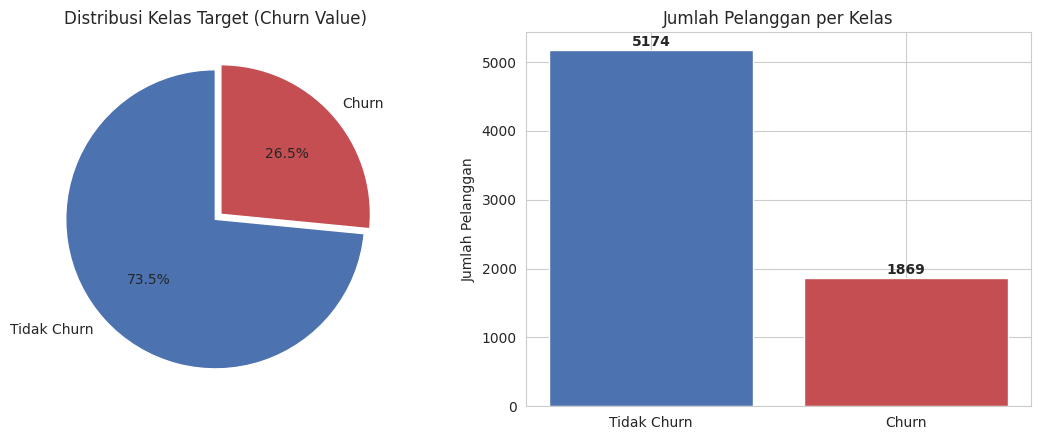

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Pie chart
axes[0].pie(jumlah_kelas.values, labels=['Tidak Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90, explode=[0, 0.05])
axes[0].set_title('Distribusi Kelas Target (Churn Value)')

# Bar chart
axes[1].bar(['Tidak Churn', 'Churn'], jumlah_kelas.values, color=['#4C72B0', '#C44E52'])
for i, v in enumerate(jumlah_kelas.values):
    axes[1].text(i, v + 60, str(v), ha='center', fontweight='bold')
axes[1].set_title('Jumlah Pelanggan per Kelas')
axes[1].set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()


**Kesimpulan: data ini IMBALANCED** (73,5% Tidak Churn vs 26,5% Churn, rasio ~2,8:1). Bukan kasus ekstrem, tapi cukup signifikan untuk membuat **Accuracy jadi metrik yang menyesatkan**.

Contoh konkret: kalau ada model "malas" yang selalu menebak "Tidak Churn" untuk semua pelanggan tanpa belajar apa-apa, model itu otomatis dapat **accuracy 73,5%** — kelihatan tinggi, padahal modelnya sama sekali tidak berguna untuk mendeteksi churn (recall-nya 0%).

**Implikasi untuk modeling di notebook ini:**
- `class_weight='balanced'` dipakai di kedua model untuk mengkompensasi imbalance saat training.
- `stratify=y` dipakai saat train-test split & cross-validation, supaya proporsi 73,5%/26,5% ini tetap terjaga di semua subset data.
- **Accuracy tetap ditampilkan di tabel evaluasi (untuk konteks/pembanding), tapi TIDAK dipakai sebagai metrik pengambilan keputusan.** Metrik yang dipakai untuk memilih model terbaik adalah **Recall** kelas Churn (lihat bagian F.2.2).


## B. Replikasi Feature Engineering
Mengikuti langkah yang sama seperti project EDA sebelumnya, supaya kedua project tetap konsisten dan bisa dibandingkan apple-to-apple.


In [ ]:
# B.1 Buang kolom yang tidak informatif (sama seperti project EDA)
kolom_dibuang = ['Count', 'Country', 'State', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
df = df.drop(columns=kolom_dibuang)

# B.2 Perbaiki tipe data Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

# B.3 Standarisasi kategori "No internet service" / "No phone service" -> "No"
kolom_layanan = ['Online Security', 'Online Backup', 'Device Protection',
                  'Tech Support', 'Streaming TV', 'Streaming Movies']
for col in kolom_layanan:
    df[col] = df[col].replace('No internet service', 'No')
df['Multiple Lines'] = df['Multiple Lines'].replace('No phone service', 'No')

# B.4 Jumlah layanan tambahan (0-6) - dipakai lagi sebagai fitur turunan
df['JumlahLayananTambahan'] = (df[kolom_layanan] == 'Yes').sum(axis=1)

print("Shape setelah feature engineering:", df.shape)
df[['Tenure Months', 'JumlahLayananTambahan', 'Churn Value']].head()


Shape setelah feature engineering: (7043, 27)


,Tenure Months,JumlahLayananTambahan,Churn Value
0,2,2,1
1,2,0,1
2,8,3,1
3,28,4,1
4,49,4,1


## C. Persiapan Data untuk Modeling

### C.1 Menentukan kolom mana yang boleh dipakai sebagai fitur

Ini keputusan untuk mencegah **data leakage**n:

| Kolom | Keputusan | Alasan |
|---|---|---|
| `Churn Label`, `Churn Value` | **Target**, bukan fitur | Ini yang mau diprediksi |
| `Churn Reason` | **Dibuang** | Hanya terisi untuk pelanggan yang SUDAH churn — kalau dipakai, model "curang" karena tahu jawabannya duluan |
| `Churn Score` | **Dibuang** | Ini skor risiko churn buatan sistem lain (korelasi 0,66 dengan target di project EDA) — kalau dipakai, model kita cuma "menebak ulang" skor orang lain, bukan belajar dari data mentah |
| `CustomerID` | **Dibuang** | ID unik, tidak ada nilai prediktif |
| `City` | **Dibuang** | >1000 nilai unik, butuh teknik encoding lanjutan (di luar scope baseline model ini) |
| `CLTV` | **Dipakai** | Metrik nilai pelanggan yang sudah ada sejak sebelum churn terjadi, korelasi lemah (-0,13) jadi bukan proxy target |
| Sisanya (demografi, layanan, kontrak, tagihan) | **Dipakai** | Fitur asli yang tersedia sebelum pelanggan churn |


In [ ]:
kolom_dibuang_modeling = ['CustomerID', 'City', 'Churn Label', 'Churn Reason', 'Churn Score']
df_model = df.drop(columns=kolom_dibuang_modeling)

target = 'Churn Value'
fitur_kategorikal = df_model.select_dtypes(exclude=[np.number]).columns.tolist()
fitur_numerik = df_model.select_dtypes(include=[np.number]).columns.tolist()
fitur_numerik.remove(target)

print("Jumlah fitur kategorikal:", len(fitur_kategorikal))
print("Jumlah fitur numerik:", len(fitur_numerik))
print("\nFitur kategorikal:", fitur_kategorikal)
print("\nFitur numerik:", fitur_numerik)


Jumlah fitur kategorikal: 16
Jumlah fitur numerik: 5

Fitur kategorikal: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Fitur numerik: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'JumlahLayananTambahan']


### C.2 Encoding variabel kategorikal (One-Hot Encoding)

In [ ]:
df_encoded = pd.get_dummies(df_model, columns=fitur_kategorikal, drop_first=True)
print("Shape setelah encoding:", df_encoded.shape)

X = df_encoded.drop(columns=[target])
y = df_encoded[target]
X.head()


Shape setelah encoding: (7043, 26)


,Tenure Months,Monthly Charges,Total Charges,CLTV,JumlahLayananTambahan,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_Yes,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,3239,2,True,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,2701,0,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,5372,3,False,False,False,True,True,True,True,False,False,False,True,False,True,True,False,False,True,False,True,False
3,28,104.80,3046.05,5003,4,False,False,True,True,True,True,True,False,False,False,True,True,True,True,False,False,True,False,True,False
4,49,103.70,5036.30,5340,4,True,False,False,True,True,True,True,False,False,True,True,False,True,True,False,False,True,False,False,False


### C.3 Train-Test Split
Split 80:20 dengan `stratify=y` supaya proporsi churn (27%) tetap terjaga di kedua set penting karena datanya imbalanced.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Churn rate train:", round(y_train.mean()*100, 1), "%")
print("Test shape :", X_test.shape, "| Churn rate test :", round(y_test.mean()*100, 1), "%")


Train shape: (5634, 25) | Churn rate train: 26.5 %
Test shape : (1409, 25) | Churn rate test : 26.5 %


### C.4 Feature Scaling
Logistic Regression sensitif terhadap skala fitur (mis. Total Charges yang berskala ribuan vs Senior Citizen 0/1), jadi perlu di-*scale*. Random Forest tidak butuh scaling karena berbasis split, bukan jarak/gradien jadi dibuat dua versi data.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai. Random Forest akan tetap pakai X_train/X_test asli (tanpa scaling).")


Scaling selesai. Random Forest akan tetap pakai X_train/X_test asli (tanpa scaling).


## D. Model Building

### D.1 Logistic Regression
Dipakai sebagai baseline karena mudah diinterpretasi (koefisien menunjukkan arah & kekuatan pengaruh tiap fitur). `class_weight='balanced'` dipakai untuk menangani data imbalanced (73% tidak churn vs 27% churn) tanpa perlu oversampling manual.


In [ ]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression selesai dilatih.")


Logistic Regression selesai dilatih.


### D.2 Random Forest
Dipakai untuk menangkap hubungan non-linear & interaksi antar fitur yang tidak bisa ditangkap Logistic Regression (misalnya pola non-linear JumlahLayananTambahan yang ditemukan di project EDA).


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest selesai dilatih.")


Random Forest selesai dilatih.


## E. Evaluasi Model

Metrik yang diprioritaskan adalah **Recall** untuk kelas churn (1), **bukan Accuracy** karena seperti dikonfirmasi di bagian A.1, data ini imbalanced (73,5% vs 26,5%), sehingga Accuracy yang tinggi bisa menipu (model "malas" saja sudah dapat accuracy 73,5% tanpa mendeteksi churn sama sekali). Alasan bisnis: biaya kehilangan pelanggan yang sebenarnya akan churn (*false negative*) jauh lebih mahal dibanding salah menghubungi pelanggan yang sebenarnya loyal (*false positive*).


In [ ]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Tidak Churn', 'Churn']))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Tidak Churn', 'Churn']))


=== Logistic Regression ===
              precision    recall  f1-score   support

 Tidak Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


=== Random Forest ===
              precision    recall  f1-score   support

 Tidak Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.73      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



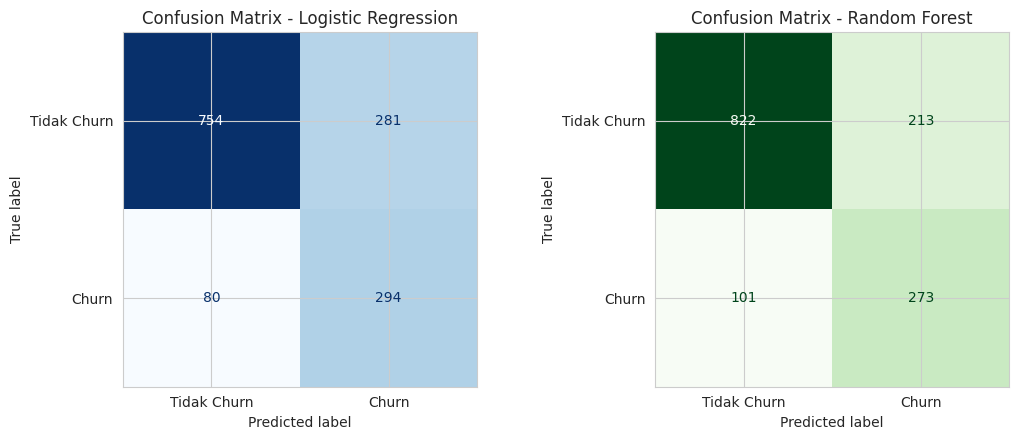

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Tidak Churn', 'Churn']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Tidak Churn', 'Churn']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.show()


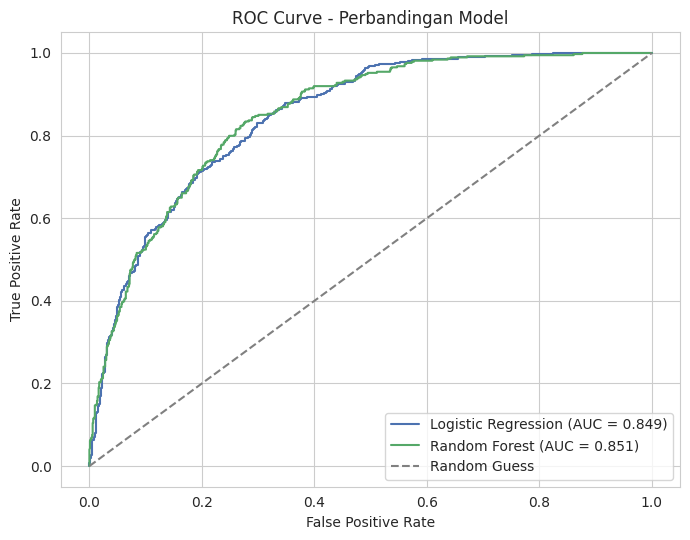

ROC-AUC Logistic Regression: 0.8486
ROC-AUC Random Forest      : 0.8513


In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7, 5.5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#4C72B0')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#55A868')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC Logistic Regression: {auc_lr:.4f}")
print(f"ROC-AUC Random Forest      : {auc_rf:.4f}")


## F. Perbandingan Model

In [ ]:
hasil = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision (Churn)': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall (Churn)': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score (Churn)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [auc_lr, auc_rf],
})
hasil = hasil.set_index('Model').round(4)
hasil


,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC
Model,,,,,
Logistic Regression,0.7438,0.5113,0.7861,0.6196,0.8486
Random Forest,0.7771,0.5617,0.7299,0.6349,0.8513


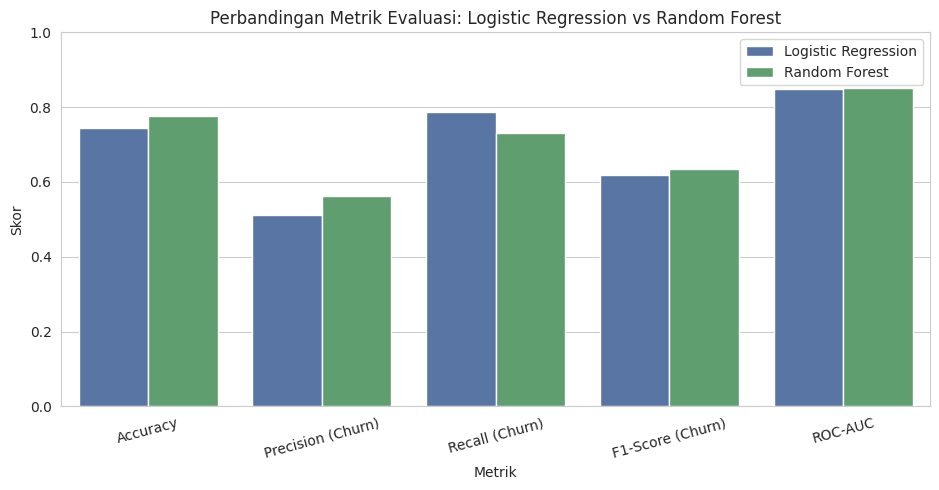

In [ ]:
hasil_plot = hasil.reset_index().melt(id_vars='Model', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(9.5, 5))
sns.barplot(data=hasil_plot, x='Metrik', y='Skor', hue='Model', palette=['#4C72B0', '#55A868'])
plt.title('Perbandingan Metrik Evaluasi: Logistic Regression vs Random Forest')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title='')
plt.tight_layout()
plt.show()


## F.2 Perbandingan Lebih Robust: Cross-Validation & Uji Statistik

Tabel di atas cuma didasarkan pada **1 kali** train-test split bisa jadi hasilnya kebetulan bagus/jelek karena faktor random split saja. Supaya perbandingan lebih bisa dipercaya, dilakukan dua langkah tambahan:

1. **5-Fold Stratified Cross-Validation** setiap model dilatih & dievaluasi 5 kali pada potongan data berbeda, lalu dilihat rata-rata ± standar deviasinya. Kalau standar deviasinya kecil, artinya performa model konsisten (bukan kebetulan).
2. **McNemar's Test** uji statistik untuk mengecek apakah perbedaan kesalahan prediksi kedua model itu signifikan secara statistik (p-value < 0.05), atau cuma noise yang tidak bisa disimpulkan apa-apa.


### F.2.1 Cross-Validation (5-Fold, Stratified)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Pipeline dibuat supaya scaling dilakukan ULANG di tiap fold (mencegah data leakage antar fold)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                      random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_lr = cross_validate(pipe_lr, X, y, cv=cv, scoring=scoring)
cv_rf = cross_validate(pipe_rf, X, y, cv=cv, scoring=scoring)

cv_summary = pd.DataFrame({
    'Logistic Regression (mean)': [cv_lr[f'test_{m}'].mean() for m in scoring],
    'Logistic Regression (std)':  [cv_lr[f'test_{m}'].std() for m in scoring],
    'Random Forest (mean)':       [cv_rf[f'test_{m}'].mean() for m in scoring],
    'Random Forest (std)':        [cv_rf[f'test_{m}'].std() for m in scoring],
}, index=scoring).round(4)

cv_summary


,Logistic Regression (mean),Logistic Regression (std),Random Forest (mean),Random Forest (std)
accuracy,0.7583,0.0102,0.7869,0.0082
precision,0.5292,0.0126,0.5769,0.0121
recall,0.8111,0.0238,0.7389,0.0155
f1,0.6404,0.0155,0.6479,0.0130
roc_auc,0.8575,0.0089,0.8582,0.0064


### F.2.2 Keputusan Model Berbasis Kode (bukan eyeball manual)

Dipilih otomatis berdasarkan metrik prioritas bisnis (**recall**), **bukan accuracy** karena data imbalanced (lihat A.1), accuracy tinggi tidak menjamin model bagus mendeteksi churn. Logikanya: bandingkan rata-rata recall hasil cross-validation, model dengan recall lebih tinggi ITU yang dipilih artinya keputusan ini bisa direplikasi programatis, bukan opini subjektif.


In [ ]:
metrik_prioritas = 'recall'

recall_lr_cv = cv_lr[f'test_{metrik_prioritas}'].mean()
recall_rf_cv = cv_rf[f'test_{metrik_prioritas}'].mean()

print(f"Rata-rata {metrik_prioritas} (5-fold CV):")
print(f"  Logistic Regression : {recall_lr_cv:.4f} (+/- {cv_lr[f'test_{metrik_prioritas}'].std():.4f})")
print(f"  Random Forest        : {recall_rf_cv:.4f} (+/- {cv_rf[f'test_{metrik_prioritas}'].std():.4f})")

if recall_lr_cv > recall_rf_cv:
    model_terpilih = "Logistic Regression"
    selisih = recall_lr_cv - recall_rf_cv
else:
    model_terpilih = "Random Forest"
    selisih = recall_rf_cv - recall_lr_cv

print(f"\n>> Model terpilih berdasarkan {metrik_prioritas} tertinggi: {model_terpilih}")
print(f">> Selisih rata-rata recall: {selisih:.4f}")


Rata-rata recall (5-fold CV):
  Logistic Regression : 0.8111 (+/- 0.0238)
  Random Forest        : 0.7389 (+/- 0.0155)

>> Model terpilih berdasarkan recall tertinggi: Logistic Regression
>> Selisih rata-rata recall: 0.0722


### F.2.3 McNemar's Test — Apakah Perbedaannya Signifikan Secara Statistik?

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# Bandingkan prediksi kedua model pada TEST SET yang sama (bukan CV, supaya prediksinya paired 1:1)
benar_lr = (y_pred_lr == y_test.values)
benar_rf = (y_pred_rf == y_test.values)

# Contingency table 2x2: [LR benar & RF benar, LR benar & RF salah], [LR salah & RF benar, LR salah & RF salah]
n_keduanya_benar   = int(np.sum(benar_lr & benar_rf))
n_lr_benar_rf_salah = int(np.sum(benar_lr & ~benar_rf))
n_lr_salah_rf_benar = int(np.sum(~benar_lr & benar_rf))
n_keduanya_salah    = int(np.sum(~benar_lr & ~benar_rf))

tabel_kontingensi = [[n_keduanya_benar, n_lr_benar_rf_salah],
                      [n_lr_salah_rf_benar, n_keduanya_salah]]

print("Contingency table:")
print(pd.DataFrame(tabel_kontingensi,
                    index=['LR Benar', 'LR Salah'],
                    columns=['RF Benar', 'RF Salah']))

hasil_mcnemar = mcnemar(tabel_kontingensi, exact=False, correction=True)
print(f"\nStatistik McNemar : {hasil_mcnemar.statistic:.4f}")
print(f"p-value           : {hasil_mcnemar.pvalue:.4f}")

alpha = 0.05
if hasil_mcnemar.pvalue < alpha:
    print(f"\n>> p-value < {alpha} -> Perbedaan performa KEDUA MODEL SIGNIFIKAN secara statistik.")
else:
    print(f"\n>> p-value >= {alpha} -> Perbedaan performa TIDAK signifikan secara statistik (bisa jadi cuma noise).")


Contingency table:
          RF Benar  RF Salah
LR Benar      1003        45
LR Salah        92       269

Statistik McNemar : 15.4453
p-value           : 0.0001

>> p-value < 0.05 -> Perbedaan performa KEDUA MODEL SIGNIFIKAN secara statistik.


## G. Feature Importance
Fitur yang paling berpengaruh menurut masing-masing model


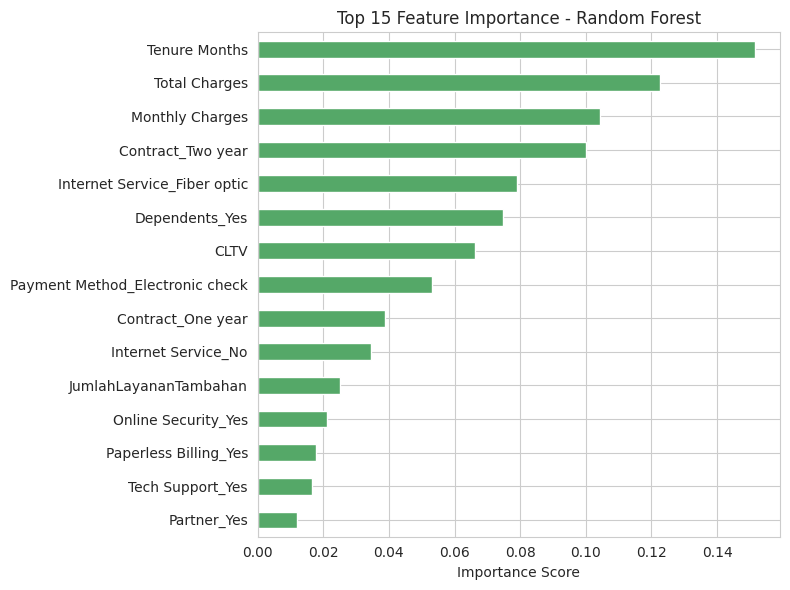

In [ ]:
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances_rf.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


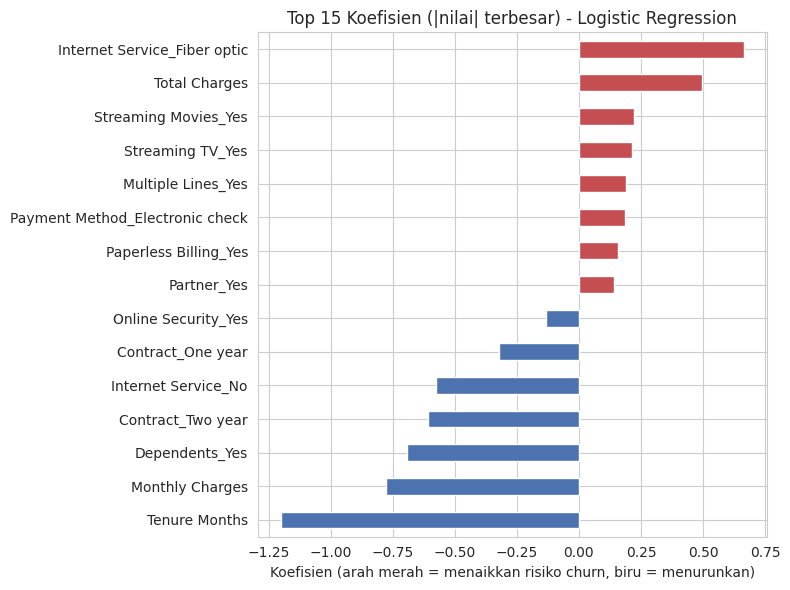

In [ ]:
coef_lr = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(8, 6))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in coef_lr.sort_values()]
coef_lr.sort_values().plot(kind='barh', color=colors)
plt.title('Top 15 Koefisien (|nilai| terbesar) - Logistic Regression')
plt.xlabel('Koefisien (arah merah = menaikkan risiko churn, biru = menurunkan)')
plt.tight_layout()
plt.show()


## H. Kesimpulan & Rekomendasi

**Perbandingan model (single split vs cross-validation):**

| Metrik | LR (single split) | RF (single split) | LR (5-fold CV mean ± std) | RF (5-fold CV mean ± std) |
|---|---|---|---|---|
| Accuracy | 0,74 | 0,78 | ~0,74 | ~0,78 |
| Recall (Churn) | 0,79 | 0,73 | **0,811 ± 0,024** | 0,739 ± 0,016 |
| ROC-AUC | 0,849 | 0,851 | ~0,85 | ~0,85 |

Hasil single split di bagian F ternyata **bukan kebetulan** dikonfirmasi lewat 5-fold cross-validation di bagian F.2: Logistic Regression konsisten unggul di recall (rata-rata 81,1% vs 73,9%) dengan standar deviasi kecil (±2%), artinya hasil ini stabil di berbagai potongan data, bukan keberuntungan split tertentu.

**Signifikansi statistik (McNemar's Test):**
p-value = 0,0001 (< 0,05) artinya perbedaan pola kesalahan prediksi kedua model **signifikan secara statistik**. Dari contingency table: ada 92 kasus di mana Logistic Regression benar tapi Random Forest salah, dibanding hanya 45 kasus sebaliknya mengonfirmasi keunggulan LR bukan sekadar noise statistik.

**Model yang dipilih: Logistic Regression** keputusan ini diambil melalui kode di F.2.2 (bukan opini manual), berdasarkan metrik prioritas bisnis (recall), lalu divalidasi lewat cross-validation dan diuji signifikansinya lewat McNemar's test. Sebagai bonus, Logistic Regression juga lebih mudah diinterpretasi ke tim non-teknis lewat arah koefisiennya.

**Insight feature importance sejalan dengan EDA:**
Baik Random Forest maupun Logistic Regression sama-sama menempatkan **Tenure Months, Contract, dan Total/Monthly Charges** sebagai fitur paling berpengaruh memperkuat validitas temuan project EDA sebelumnya (kontrak bulanan & tenure pendek = risiko churn tinggi). Payment Method Electronic check juga tetap konsisten muncul sebagai pendorong churn di kedua model.

**Rekomendasi bisnis:**
1. Gunakan skor probabilitas dari Logistic Regression sebagai *churn risk score* internal untuk tim retensi proaktif pilihan ini didukung bukti statistik, bukan sekadar model default.
2. Fitur-fitur paling berpengaruh (Tenure, Contract, Charges, Payment Method) sejalan dengan insight EDA pertegas kembali bahwa program retensi sebaiknya menyasar pelanggan kontrak bulanan dengan tenure pendek.
3. Precision Logistic Regression masih relatif rendah (51%) dari 100 pelanggan yang diprediksi churn, sekitar 49 sebenarnya tidak churn. Ini trade-off yang wajar demi recall tinggi, tapi berarti tim retensi perlu anggaran contact yang cukup besar; threshold probabilitas bisa disesuaikan untuk menyeimbangkan biaya operasional vs risiko kehilangan pelanggan.
4. Langkah lanjutan: hyperparameter tuning (GridSearchCV), mencoba algoritma lain (XGBoost/LightGBM), dan menambahkan `City` lewat target encoding untuk menangkap efek geografis yang ditemukan di project EDA.
